In [ ]:
# Extract the accuracy, F1-Scores and recall scores of the pretrained YOLO models with and without FP-Reduction
import os 
import re

path = "base_path_of_the_results_of_pretrained_model"
yolofn = sorted([x for x in os.listdir(path) if x.startswith("yolofn")])
yolofpfn = sorted([x for x in os.listdir(path) if x.startswith("yolofpfn")])


mean_accuracy = None
yolofn_pretrained_acc = []
yolofn_pretrained_f1 = []
yolofn_pretrained_recall = []
def get_confidence(text):
    match = re.search(r"confidence([0-9]*\.?[0-9]+)", text)
    if match:
        return float(match.group(1))
    return None
for conf in yolofn:
    with open(os.path.join(path, conf, "metrics_results.txt") , "r", encoding="utf-8") as f:
        lines = f.readlines()
        for i, line in enumerate(lines):
            if "Mean over all classes" in line:
                # next line should contain accuracy
                if "Accuracy" in lines[i+2] and "F1-Score" in lines[i+3]:
                    mean_accuracy = float(lines[i+2].split(":")[1].strip())
                    mean_f1score = float(lines[i+3].split(":")[1].strip())
                    mean_recallscore = float(lines[i+5].split(":")[1].strip())
                    yolofn_pretrained_acc.append((get_confidence(conf), mean_accuracy))
                    yolofn_pretrained_f1.append((get_confidence(conf), mean_f1score))
                    yolofn_pretrained_recall.append((get_confidence(conf), mean_recallscore))
                    break
                else:
                    raise(ValueError)

yolofpfn = sorted([x for x in os.listdir(path) if x.startswith("yolofpfn")])

yolofpfn_pretrained_acc = []
yolofpfn_pretrained_f1 = []
for conf in yolofpfn:
    with open(os.path.join(path, conf, "metrics_results.txt") , "r", encoding="utf-8") as f:
        lines = f.readlines()
        for i, line in enumerate(lines):
            if "Mean over all classes without Healthy:" in line:
                # next line should contain accuracy
                if "Accuracy" in lines[i+1] and "F1-Score" in lines[i+2]:
                    mean_accuracy = float(lines[i+1].split(":")[1].strip())
                    mean_f1score = float(lines[i+2].split(":")[1].strip())
                    yolofpfn_pretrained_acc.append((get_confidence(conf), mean_accuracy))
                    yolofpfn_pretrained_f1.append((get_confidence(conf), mean_f1score))
                    break
                else:
                    raise(ValueError)

In [ ]:
# Extract the accuracy, F1-Scores and recall scores of the not pretrained YOLO models with and without FP-Reduction
path = "basepath_to_notpretrained_results"
import os 
import re
yolofn = sorted([x for x in os.listdir(path) if x.startswith("yolofn")])
yolofpfn = sorted([x for x in os.listdir(path) if x.startswith("yolofpfn")])


mean_accuracy = None
yolofn_notpretrained_acc = []
yolofn_notpretrained_f1 = []
def get_confidence(text):
    match = re.search(r"confidence([0-9]*\.?[0-9]+)", text)
    if match:
        return float(match.group(1))
    return None
for conf in yolofn:
    with open(os.path.join(path, conf, "metrics_results.txt") , "r", encoding="utf-8") as f:
        lines = f.readlines()
        for i, line in enumerate(lines):
            if "Mean over all classes" in line:
                # next line should contain accuracy
                if "Accuracy" in lines[i+2] and "F1-Score" in lines[i+3]:
                    mean_accuracy = float(lines[i+2].split(":")[1].strip())
                    mean_f1score = float(lines[i+3].split(":")[1].strip())
                    yolofn_notpretrained_acc.append((get_confidence(conf), mean_accuracy))
                    yolofn_notpretrained_f1.append((get_confidence(conf), mean_f1score))
                    break
                else:
                    raise(ValueError)


yolofpfn = sorted([x for x in os.listdir(path) if x.startswith("yolofpfn")])

yolofpfn_notpretrained_acc = []
yolofpfn_notpretrained_f1 = []
for conf in yolofpfn:
    with open(os.path.join(path, conf, "metrics_results.txt") , "r", encoding="utf-8") as f:
        lines = f.readlines()
        for i, line in enumerate(lines):
            if "Mean over all classes without Healthy:" in line:
                # next line should contain accuracy
                if "Accuracy" in lines[i+1] and "F1-Score" in lines[i+2]:
                    mean_accuracy = float(lines[i+1].split(":")[1].strip())
                    mean_f1score = float(lines[i+2].split(":")[1].strip())
                    yolofpfn_notpretrained_acc.append((get_confidence(conf), mean_accuracy))
                    yolofpfn_notpretrained_f1.append((get_confidence(conf), mean_f1score))
                    break
                else:
                    raise(ValueError)


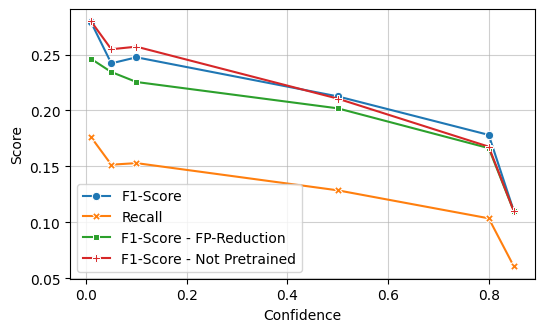

In [4]:
# Generate plot
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig = plt.figure(figsize=(6, 3.5)) 
axes = fig.add_subplot(1,1,1)

data = []

# Add pretrained F1
data += [{"Confidence": c, "Score": f, "Metric": "F1-Score"} 
         for c, f in yolofn_pretrained_f1]

# Add pretrained Recall
data += [{"Confidence": c, "Score": f, "Metric": "Recall"} 
         for c, f in yolofn_pretrained_recall]

# Add pretrained FP-Reduction
data += [{"Confidence": c, "Score": f, "Metric": "FP Reduction F1"} 
         for c, f in yolofpfn_pretrained_f1]

# Add not pretrained F1
data += [{"Confidence": c, "Score": f, "Metric": "F1-Score Not Pretrained"} 
         for c, f in yolofn_notpretrained_f1]

df_plot = pd.DataFrame(data)

sns.lineplot(
    data=df_plot,
    x="Confidence", y="Score", hue="Metric",
    style="Metric", markers=True, dashes=False, ax=axes
)

handles, labels = axes.get_legend_handles_labels()

labels = [
    "F1-Score - FP-Reduction" if lbl == "FP Reduction F1" else
    "F1-Score - Not Pretrained" if lbl == "F1-Score Not Pretrained" else
    lbl
    for lbl in labels
]

axes.set_ylabel("Confidence")
axes.set_ylabel("Score")
axes.grid(True, linestyle="-", alpha=0.6)
axes.legend(handles, labels)
plt.show()